C:\Users\Dell\AppData\Local\Temp\ipykernel_8688\1246318472.py:6: DtypeWarning: Columns (22,23,24,25,26,27,28,29,30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  csv = pd.read_csv('lista_de_espera_sisu_2022_2.csv', sep='|', encoding='latin-1')


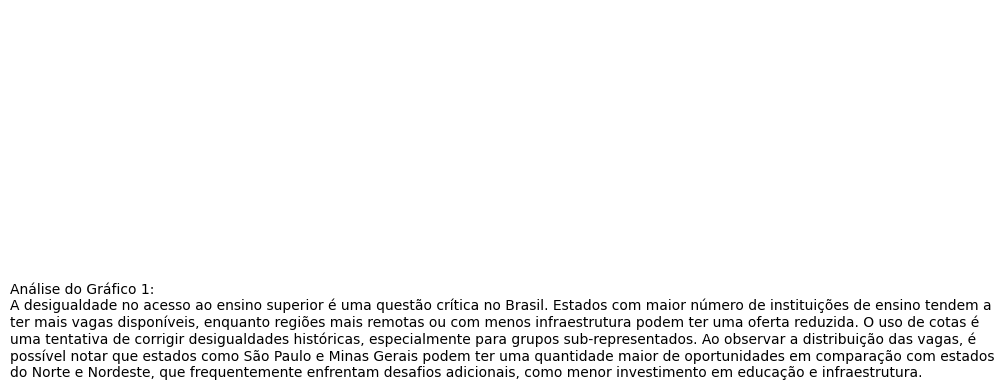

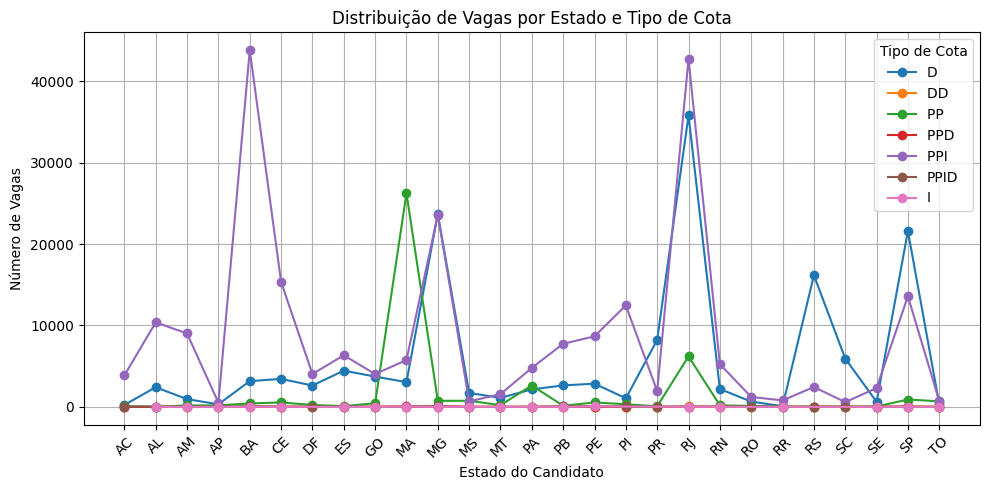

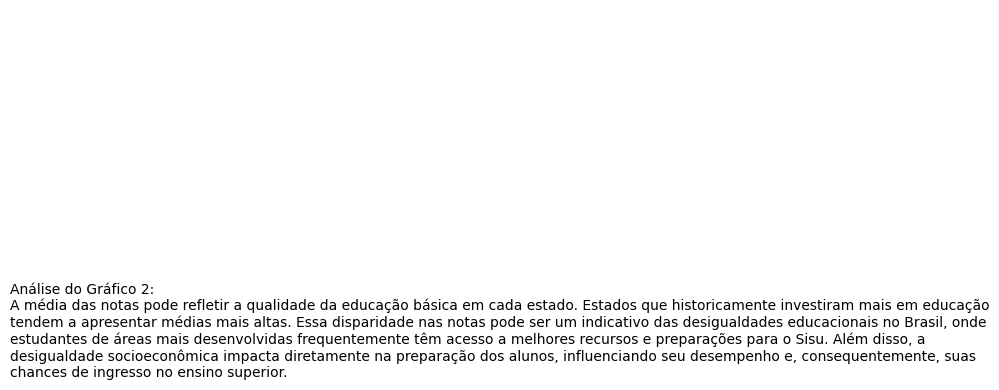

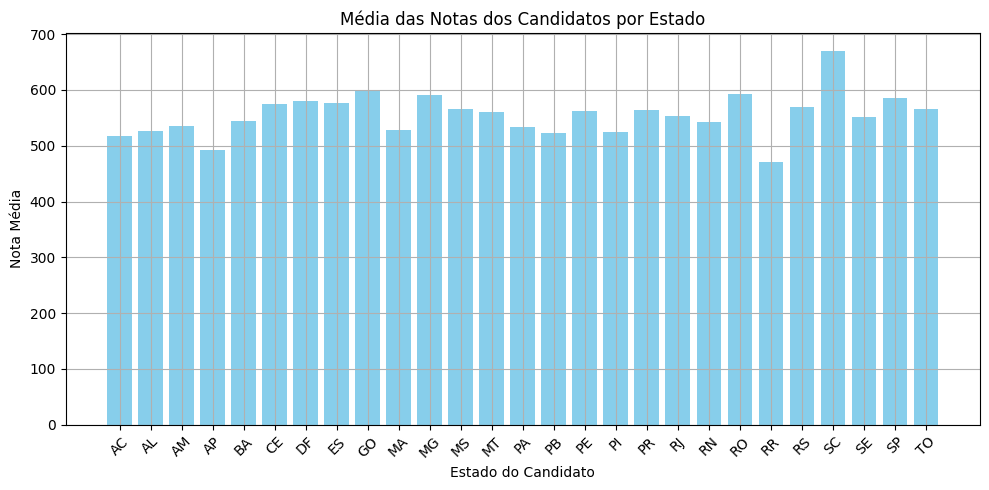

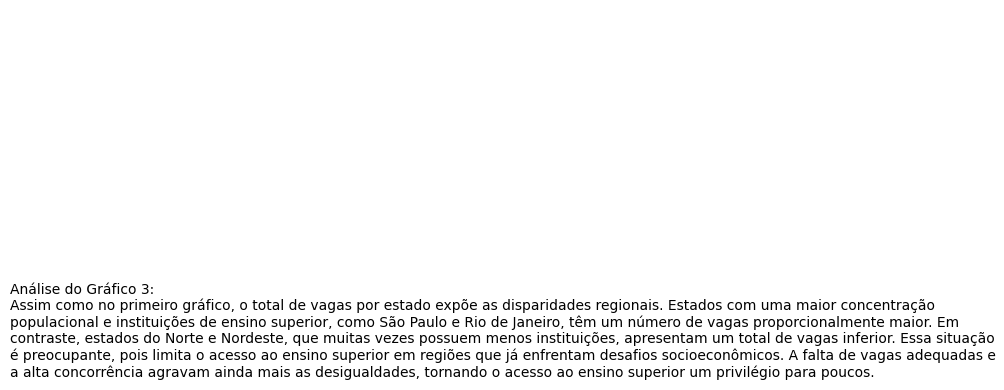

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Carregar o arquivo CSV
csv = pd.read_csv('lista_de_espera_sisu_2022_2.csv', sep='|', encoding='latin-1')

# Filtrar e limpar dados
dados = csv[['UF_CANDIDATO', 'UF_IES', 'QT_VAGAS_CONCORRENCIA', 'NOTA_CANDIDATO', 'TP_COTA']]
dados = dados.dropna(subset=['UF_CANDIDATO', 'UF_IES', 'QT_VAGAS_CONCORRENCIA', 'NOTA_CANDIDATO', 'TP_COTA'])
dados['QT_VAGAS_CONCORRENCIA'] = pd.to_numeric(dados['QT_VAGAS_CONCORRENCIA'], errors='coerce')
dados['NOTA_CANDIDATO'] = pd.to_numeric(dados['NOTA_CANDIDATO'], errors='coerce')

# Agrupamento dos dados
agrupado_uf_cota = dados.groupby(['UF_CANDIDATO', 'TP_COTA']).agg({
    'QT_VAGAS_CONCORRENCIA': 'sum',
    'NOTA_CANDIDATO': 'mean'
}).reset_index()

total_vagas_uf = dados.groupby('UF_CANDIDATO')['QT_VAGAS_CONCORRENCIA'].sum().reset_index()
media_nota_uf = dados.groupby('UF_CANDIDATO')['NOTA_CANDIDATO'].mean().reset_index()

# Criar PDF
with PdfPages('relatorio4_sisu_2022.pdf') as pdf:
    
    ### Página 1: Análise e Gráfico 1
    texto_grafico1 = (
        "Análise do Gráfico 1:\n"
        "A desigualdade no acesso ao ensino superior é uma questão crítica no Brasil. "
        "Estados com maior número de instituições de ensino tendem a ter mais vagas disponíveis, "
        "enquanto regiões mais remotas ou com menos infraestrutura podem ter uma oferta reduzida. "
        "O uso de cotas é uma tentativa de corrigir desigualdades históricas, especialmente para grupos "
        "sub-representados. Ao observar a distribuição das vagas, é possível notar que estados como "
        "São Paulo e Minas Gerais podem ter uma quantidade maior de oportunidades em comparação com estados "
        "do Norte e Nordeste, que frequentemente enfrentam desafios adicionais, como menor investimento em "
        "educação e infraestrutura."
    )
    
    plt.figure(figsize=(10, 4))  # Tamanho ajustado para análise
    plt.text(0, 0, texto_grafico1, fontsize=10, ha='left', wrap=True)
    plt.axis('off')
    plt.tight_layout()
    pdf.savefig()  # Salva a análise no PDF

    # Gráfico 1
    plt.figure(figsize=(10, 5))
    for tipo_cota in agrupado_uf_cota['TP_COTA'].unique():
        subset = agrupado_uf_cota[agrupado_uf_cota['TP_COTA'] == tipo_cota]
        plt.plot(subset['UF_CANDIDATO'], subset['QT_VAGAS_CONCORRENCIA'], marker='o', label=tipo_cota)
    
    plt.xticks(rotation=45)
    plt.title('Distribuição de Vagas por Estado e Tipo de Cota')
    plt.xlabel('Estado do Candidato')
    plt.ylabel('Número de Vagas')
    plt.legend(title='Tipo de Cota')
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()  # Salva o gráfico no PDF
 

    ### Página 2: Análise e Gráfico 2
    texto_grafico2 = (
        "Análise do Gráfico 2:\n"
        "A média das notas pode refletir a qualidade da educação básica em cada estado. "
        "Estados que historicamente investiram mais em educação tendem a apresentar médias mais altas. "
        "Essa disparidade nas notas pode ser um indicativo das desigualdades educacionais no Brasil, onde "
        "estudantes de áreas mais desenvolvidas frequentemente têm acesso a melhores recursos e preparações "
        "para o Sisu. Além disso, a desigualdade socioeconômica impacta diretamente na preparação dos alunos, "
        "influenciando seu desempenho e, consequentemente, suas chances de ingresso no ensino superior."
    )
    
    plt.figure(figsize=(10, 4))  # Tamanho ajustado para análise
    plt.text(0, 0, texto_grafico2, fontsize=10, ha='left', wrap=True)
    plt.axis('off')
    plt.tight_layout()
    pdf.savefig()  # Salva a análise no PDF
  

    # Gráfico 2
    plt.figure(figsize=(10, 5))
    plt.bar(media_nota_uf['UF_CANDIDATO'], media_nota_uf['NOTA_CANDIDATO'], color='skyblue')
    
    plt.xticks(rotation=45)
    plt.title('Média das Notas dos Candidatos por Estado')
    plt.xlabel('Estado do Candidato')
    plt.ylabel('Nota Média')
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()  # Salva o gráfico no PDF


    ### Página 3: Análise e Gráfico 3
    texto_grafico3 = (
        "Análise do Gráfico 3:\n"
        "Assim como no primeiro gráfico, o total de vagas por estado expõe as disparidades regionais. "
        "Estados com uma maior concentração populacional e instituições de ensino superior, como São Paulo "
        "e Rio de Janeiro, têm um número de vagas proporcionalmente maior. Em contraste, estados do Norte e "
        "Nordeste, que muitas vezes possuem menos instituições, apresentam um total de vagas inferior. "
        "Essa situação é preocupante, pois limita o acesso ao ensino superior em regiões que já enfrentam desafios "
        "socioeconômicos. A falta de vagas adequadas e a alta concorrência agravam ainda mais as desigualdades, "
        "tornando o acesso ao ensino superior um privilégio para poucos."
    )
    
    plt.figure(figsize=(10, 4))  # Tamanho ajustado para análise
    plt.text(0, 0, texto_grafico3, fontsize=10, ha='left', wrap=True)
    plt.axis('off')
    plt.tight_layout()
    pdf.savefig()  # Salva a análise no PDF
    plt.close()

    # Gráfico 3
    plt.figure(figsize=(10, 5))
    plt.bar(total_vagas_uf['UF_CANDIDATO'], total_vagas_uf['QT_VAGAS_CONCORRENCIA'], color='lightgreen')
    
    plt.xticks(rotation=45)
    plt.title('Total de Vagas por Estado')
    plt.xlabel('Estado do Candidato')
    plt.ylabel('Número Total de Vagas')
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()  # Salva o gráfico no PDF
    plt.close()
